In [13]:
import pandas as pd
import numpy as np
import measure as ms    # measure.py

In [14]:
class KNN:
    def __init__(self, filePath: str, k: int):
        self.data = pd.read_csv(filePath)
        self.k = k
        self.preprocess()
        self.split_data()


    def predict(self):
        predictions = [self.predict_single(x) for x in self.X_test]
        return np.array(predictions)


    def preprocess(self):
        self.data = self.data.sample(frac=1)
                
        self.X = self.data.drop(columns='target').to_numpy()
        self.Y = self.data.filter(like='target').to_numpy()

        self.X = (self.X - self.X.mean(axis = 0)) / self.X.std(axis = 0)


    def split_data(self):
        self.split_index = int(0.8 * self.X.shape[0])
        
        self.X_train = self.X[:self.split_index]
        self.X_test  = self.X[self.split_index:]

        self.Y_train = self.Y[:self.split_index]
        self.Y_test  = self.Y[self.split_index:]


    def distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))


    def predict_single(self, x):
        distances = [self.distance(x, xt) for xt in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_targets = self.Y_train[k_indices]
        positive_count = np.sum(k_targets)
        return 1 if positive_count > self.k / 2 else 0


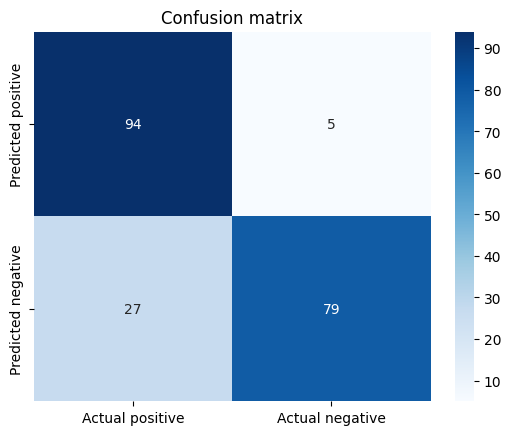

Accuracy: 0.84
Precision: 0.78
Recall: 0.95
Specificity: 0.75
F1 score: 0.85


In [ ]:
if __name__ == "__main__":
    knn = KNN("dataset/heart.csv", 3)
    
    predictions = knn.predict()
    tp, fp, fn, tn = ms.getConfusionMatrixEntries(predictions, knn.Y_test)
    ms.confusionMatrix(tp, fp, fn, tn)